In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# 1D signal 

c:\Users\zeyad\miniconda3\envs\multimodal\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\zeyad\miniconda3\envs\multimodal\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'recon signal')

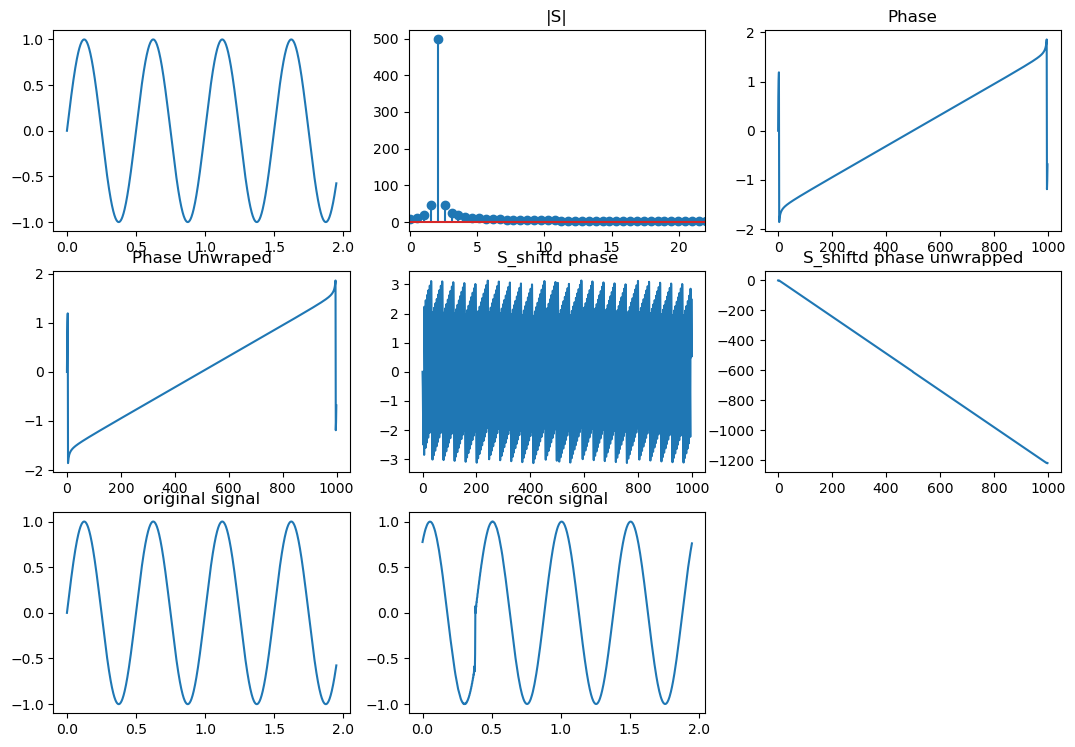

In [2]:
fs = 512
N = 1000
f = 2

t = np.arange(N) / fs

s = np.sin(2 * np.pi * f * t) # * np.sin(2 * np.pi * 10 * t) * 5
S = np.fft.fft(s)

hz = np.fft.fftfreq(N, 1/fs)
mag, phase = np.abs(S), np.angle(S)

S_shifted = S * np.exp(-1j * 2 * np.pi * hz * (-np.pi/2)) # this will shift + pi/2 90 deg positive shift
s_recon = np.fft.ifft(S_shifted)

plt.figure(figsize=(13, 12))
plt.subplot(431)
plt.plot(t, s)

plt.subplot(432)
plt.title("|S|")
plt.stem(hz, mag)
plt.xlim(-0.1, 22)

plt.subplot(433)
plt.plot(phase)
plt.title("Phase")

plt.subplot(434)
plt.plot(np.unwrap(phase))
plt.title("Phase Unwraped")

plt.subplot(435)
plt.plot(np.angle(S_shifted))
plt.title("S_shiftd phase")

plt.subplot(436)
plt.plot(np.unwrap(np.angle(S_shifted)))
plt.title("S_shiftd phase unwrapped")

plt.subplot(437)
plt.plot(t, s)
plt.title("original signal")

plt.subplot(438)
plt.plot(t, s_recon)
plt.title("recon signal")

# 2D image

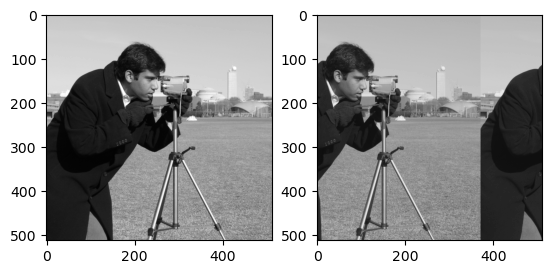

In [6]:
img = np.array(data.camera())

img_fft = np.fft.rfft2(img)

# shifting
nrows, ncols = img_fft.shape
shiftx = 71
shifty = 0
fs = 1  # uhhh not sure what to put fs really.. perhpas 1 as it is 1 pixel per data? idk...

rows_hz = np.fft.fftfreq(nrows, fs)
cols_hz = np.fft.fftfreq(ncols, fs)
col_grid, row_grid = np.meshgrid(cols_hz, rows_hz)

row_shift = np.exp(-1j * 2 * np.pi * row_grid * (-shifty))
col_shift = np.exp(-1j * 2 * np.pi * col_grid * (-shiftx))

img_fft *= row_shift * col_shift

# and i'm strugglign how to apply...

mag, phase = np.abs(img_fft), np.angle(img_fft)

recon = np.fft.irfft2(mag * np.exp(1j * phase))

plt.subplot(121)
plt.imshow(img, cmap="gray")
plt.subplot(122)
plt.imshow(recon, cmap="gray")